# Tech Company Fundamentals vs Stock Performance

Research Question : Do companies with stronger revenue growth and operating performance also show stronger stock-market performance? 
This project compares Apple, Microsoft, Amazon, Nvidia, and Alphabet over the 2021–2025 period using Python, SQL, and Excel.

In [1]:
%pip install pandas matplotlib numpy yfinance

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\louis\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt


## 1) Data Collection and Preparation

Historical stock-price data and annual financial-statement data are downloaded for the five selected companies.

The data is then cleaned and used to calculate stock-market and fundamental performance measures.

In [3]:
%run 01_download_data.py

Downloaded price rows: 1255
Downloaded financial rows: 21


In [4]:
%run 02_clean_and_calculate.py

  ticker    company                       sector  total_return  \
0   AAPL      Apple                   Technology        1.1581   
1   AMZN     Amazon             Consumer / Cloud        0.4487   
2  GOOGL   Alphabet  Digital Advertising / Cloud        2.6540   
3   MSFT  Microsoft                   Technology        1.3153   
4   NVDA     Nvidia               Semiconductors       13.2620   

   annualized_return  annualized_volatility  sharpe_ratio  revenue_cagr  \
0             0.1667                 0.2786        0.4907        0.0181   
1             0.0771                 0.3511        0.1343        0.1173   
2             0.2966                 0.3115        0.8561        0.1251   
3             0.1833                 0.2571        0.5961        0.1612   
4             0.7036                 0.5222        1.2899        1.0005   

   latest_operating_margin  
0                   0.3197  
1                   0.1116  
2                   0.3203  
3                   0.4678  
4      

## 2) Final Dataset

The processed dataset combines market-performance measures with company fundamentals.

In [5]:
data = pd.read_csv('../data/processed/company_summary.csv')
data.head()


,ticker,company,sector,total_return,annualized_return,annualized_volatility,sharpe_ratio,revenue_cagr,latest_operating_margin
0,AAPL,Apple,Technology,1.158056,0.166725,0.278626,0.490710,0.018125,0.319708
1,AMZN,Amazon,Consumer / Cloud,0.448678,0.077133,0.351060,0.134260,0.117313,0.111553
2,GOOGL,Alphabet,Digital Advertising / Cloud,2.654011,0.296631,0.311455,0.856082,0.125117,0.320326
3,MSFT,Microsoft,Technology,1.315276,0.183288,0.257143,0.596121,0.161240,0.467808
4,NVDA,Nvidia,Semiconductors,13.261982,0.703627,0.522247,1.289863,1.000451,0.603817


## 3) Summary Statistics

The following table provides descriptive statistics for the variables used in the analysis.

In [6]:
data.describe()


,total_return,annualized_return,annualized_volatility,sharpe_ratio,revenue_cagr,latest_operating_margin
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,3.767600,0.285481,0.344106,0.673407,0.284449,0.364642
std,5.367081,0.246437,0.105710,0.431109,0.403760,0.184313
min,0.448678,0.077133,0.257143,0.134260,0.018125,0.111553
25%,1.158056,0.166725,0.278626,0.490710,0.117313,0.319708
50%,1.315276,0.183288,0.311455,0.596121,0.125117,0.320326
75%,2.654011,0.296631,0.351060,0.856082,0.161240,0.467808
max,13.261982,0.703627,0.522247,1.289863,1.000451,0.603817


## 4) Stock-Market Performance

The companies are compared using annualized return, annualized volatility, and the Sharpe ratio.

The Sharpe ratio measures historical return relative to the amount of risk taken.

In [7]:
data[['company','annualized_return','annualized_volatility','sharpe_ratio']].sort_values('sharpe_ratio', ascending=False)


,company,annualized_return,annualized_volatility,sharpe_ratio
4,Nvidia,0.703627,0.522247,1.289863
2,Alphabet,0.296631,0.311455,0.856082
3,Microsoft,0.183288,0.257143,0.596121
0,Apple,0.166725,0.278626,0.490710
1,Amazon,0.077133,0.351060,0.134260


### Return and Risk Comparison

The following charts compare the historical return and volatility of the five companies.

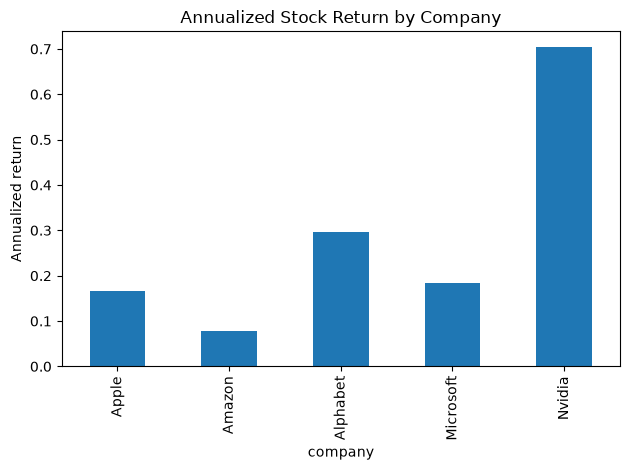

In [8]:
data.plot(x='company', y='annualized_return', kind='bar', legend=False)
plt.ylabel('Annualized return')
plt.title('Annualized Stock Return by Company')
plt.tight_layout()
plt.show()


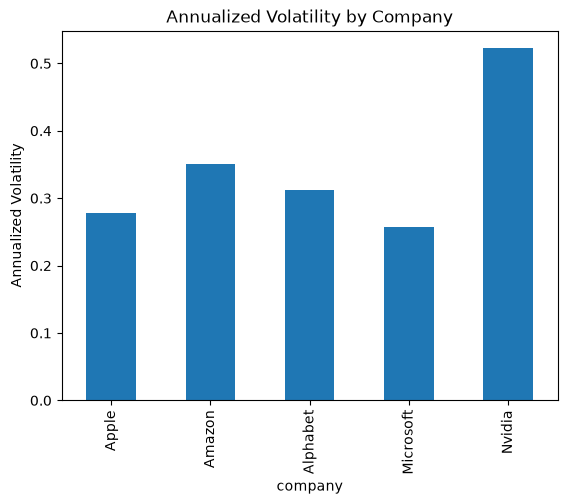

In [9]:
data.plot(
    x="company",
    y="annualized_volatility",
    kind="bar",
    legend=False
)

plt.ylabel("Annualized Volatility")
plt.title("Annualized Volatility by Company")
plt.show()

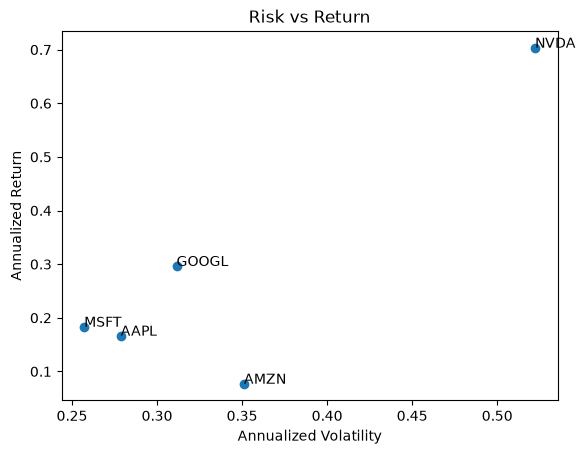

In [10]:
plt.scatter(data['annualized_volatility'], data['annualized_return'])
for _, row in data.iterrows():
    plt.annotate(row['ticker'], (row['annualized_volatility'], row['annualized_return']))
plt.xlabel('Annualized Volatility')
plt.ylabel('Annualized Return')
plt.title('Risk vs Return')
plt.show()


## 5) Company Fundamentals vs Stock Performance

Revenue CAGR measures the compound annual growth rate of each company's revenue.

The following chart examines whether companies with stronger revenue growth also experienced stronger stock-market performance.

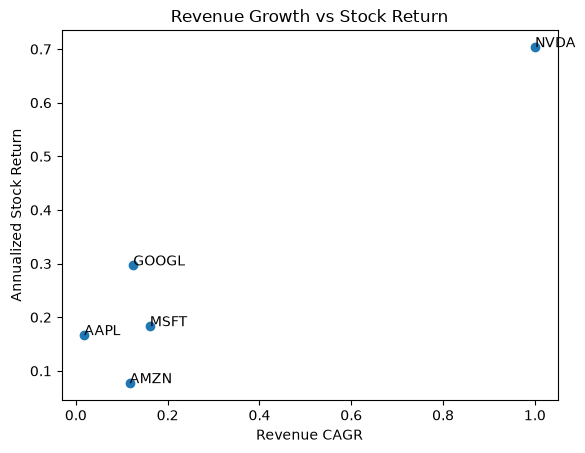

In [11]:
plt.scatter(data["revenue_cagr"], data["annualized_return"])

for i in range(len(data)):
    plt.annotate(data["ticker"][i],(data["revenue_cagr"][i], data["annualized_return"][i]))

plt.xlabel("Revenue CAGR")
plt.ylabel("Annualized Stock Return")
plt.title("Revenue Growth vs Stock Return")
plt.show()

## 6. Correlation Analysis

The correlation matrix examines the relationships between stock returns, revenue growth, and operating margins.

Because the sample contains only five companies, these correlations should be interpreted as descriptive rather than causal.

In [12]:
data[["annualized_return", "revenue_cagr", "latest_operating_margin"]].corr()

,annualized_return,revenue_cagr,latest_operating_margin
annualized_return,1.000000,0.946362,0.809306
revenue_cagr,0.946362,1.000000,0.738620
latest_operating_margin,0.809306,0.738620,1.000000


## 7. SQL Analysis

The processed financial data is stored in a SQLite database.

SQL is then used to query company returns, risk-adjusted performance, and fundamental growth measures.

In [13]:
%run 03_build_database.py

Database created: C:\Users\louis\Downloads\tech-financial-analysis\tech-financial-analysis\data\financial_analysis.db


In [14]:
%run 04_sql_analysis.py

\n HIGHEST_ANNUALIZED_RETURNS
     company  annualized_return
0     Nvidia             0.7036
1   Alphabet             0.2966
2  Microsoft             0.1833
3      Apple             0.1667
4     Amazon             0.0771
\n HIGHEST_SHARPE_RATIOS
     company  sharpe_ratio
0     Nvidia        1.2899
1   Alphabet        0.8561
2  Microsoft        0.5961
3      Apple        0.4907
4     Amazon        0.1343
\n REVENUE_GROWTH_VS_RETURN
     company  revenue_cagr  annualized_return  latest_operating_margin
0     Nvidia        1.0005             0.7036                   0.6038
1  Microsoft        0.1612             0.1833                   0.4678
2   Alphabet        0.1251             0.2966                   0.3203
3     Amazon        0.1173             0.0771                   0.1116
4      Apple        0.0181             0.1667                   0.3197


## 8. Conclusion

This project examined the relationship between company fundamentals and stock-market performance for five major technology companies.

The analysis compared historical stock returns, volatility, Sharpe ratios, revenue growth, and operating margins.

The results provide a descriptive view of whether stronger fundamental growth coincided with stronger historical stock performance. However, stock prices are also influenced by factors such as valuation, investor expectations, interest rates, and broader economic conditions.

Because the analysis includes only five companies and covers a limited time period, the results should not be interpreted as evidence of causation.